In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
from skimage.feature import peak_local_max

In [10]:
def fft_data(tif_image_path):

    image = Image.open(tif_image_path)
    image_array = np.array(image)
    #print(image_array)

    # Perform 2D FFT using scipy.fft
    fft_result = fft2(image_array)  # 2D FFT
    fft_shifted = fftshift(fft_result)  # Shift zero frequency to the center
    fft_magnitude = np.abs(fft_shifted)  # Magnitude spectrum

    # Plot the original image and its FFT magnitude spectrum
    plt.figure(figsize=(12, 6))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(image_array, cmap='gray')
    plt.title("Original Image")
    plt.axis()

    # FFT Magnitude Spectrum
    plt.subplot(1, 2, 2)
    plt.imshow(np.log1p(fft_magnitude)) 
    plt.axis()

    plt.tight_layout()
    plt.show()

    coordinates = peak_local_max(fft_magnitude, min_distance=5, threshold_abs=1)
    center = (fft_magnitude.shape[0]//2, fft_magnitude.shape[1]//2)
    
    # Convert detected peaks to polar coordinates (relative to center)
    angles = []
    for coord in coordinates:
        row, col = coord
        dy = row - center[0]
        dx = col - center[1]
        angle = np.arctan2(dy, dx)  # Angle in radians
        angles.append(angle)

    angles = np.array(angles)  # Convert to numpy array
    print(angles)
    # Simple K-means implementation
    def kmeans_1d(data, k=2, max_iter=100, tol=1e-6):
        # Initialize cluster centers randomly
        np.random.seed(0)
        centers = np.random.choice(data, size=k, replace=False)
        
        for iteration in range(max_iter):
            # Assign points to the nearest cluster center
            clusters = [[] for _ in range(k)]
            for angle in data:
                distances = np.abs(angle - centers)
                cluster_idx = np.argmin(distances)
                clusters[cluster_idx].append(angle)
            
            # Calculate new centers as mean of the clusters
            new_centers = np.array([np.mean(cluster) for cluster in clusters])
            
            # Check for convergence (center change below tolerance)
            if np.all(np.abs(new_centers - centers) < tol):
                break
            
            centers = new_centers

        return centers, clusters

    # Apply k-means
    centers, clusters = kmeans_1d(angles)

    # Compute the twist angle
    twist_angle_rad = np.abs(centers[0] - centers[1])
    twist_angle_deg = np.degrees(twist_angle_rad)

    print(f"Twist Angle: {twist_angle_deg:.2f} degrees")

    '''# Visualization
    plt.figure(figsize=(8, 8))
    plt.imshow(np.log(fft_magnitude + 1), cmap='gray')
    plt.scatter(coordinates[:, 1], coordinates[:, 0], color='white', s=20, label='Detected Peaks')

    # Color-code clusters
    for i, cluster in enumerate(clusters):
        color = 'red' if i == 0 else 'blue'
        cluster_coords = [coordinates[np.isclose(angles, angle)] for angle in cluster]
        cluster_coords = np.vstack(cluster_coords)
        plt.scatter(cluster_coords[:, 1], cluster_coords[:, 0], color=color, label=f'Cluster {i+1}')

    plt.legend()
    plt.title("Clustering FFT Peaks (Manual K-Means)")
    plt.show()'''

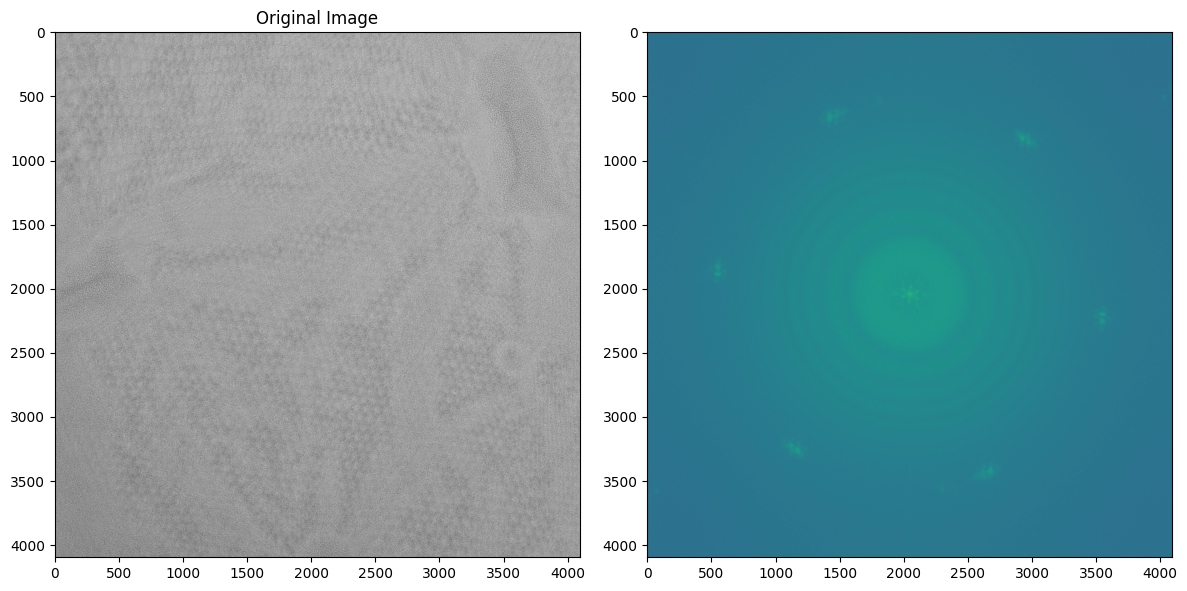

[ 0.          3.14159265  0.         ...  0.8175797  -2.38088732
  0.76070534]
Twist Angle: 180.03 degrees


In [11]:
tif_image_path = "200kV_100kX_OneView_0040.tif"
fft_data(tif_image_path)